# IV. VIsualisation

**Objectif**: Créer des graphiques professionnels, lisibles, exportées dans outputs/figures

In [1]:
import sys, os
sys.path.append(os.path.abspath('..'))

import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

from src.viz import (
    set_project_style,
    plot_churn_distribution,
    plot_churn_by_category,
    plot_churn_vs_tenure,
    plot_correlation_heatmp,
)

from src.features import add_tenure_group


DATA_PATH = '../data/processed/telco_eda.csv'
df_eda = pd.read_csv(DATA_PATH)
df_eda = add_tenure_group(df_eda)

print("Données chargées")
set_project_style()

Données chargées


## 1. Graphique 1 - Distribution du Churn

Sauvegarder: ../outputs/figures/01_churn_distribution.png


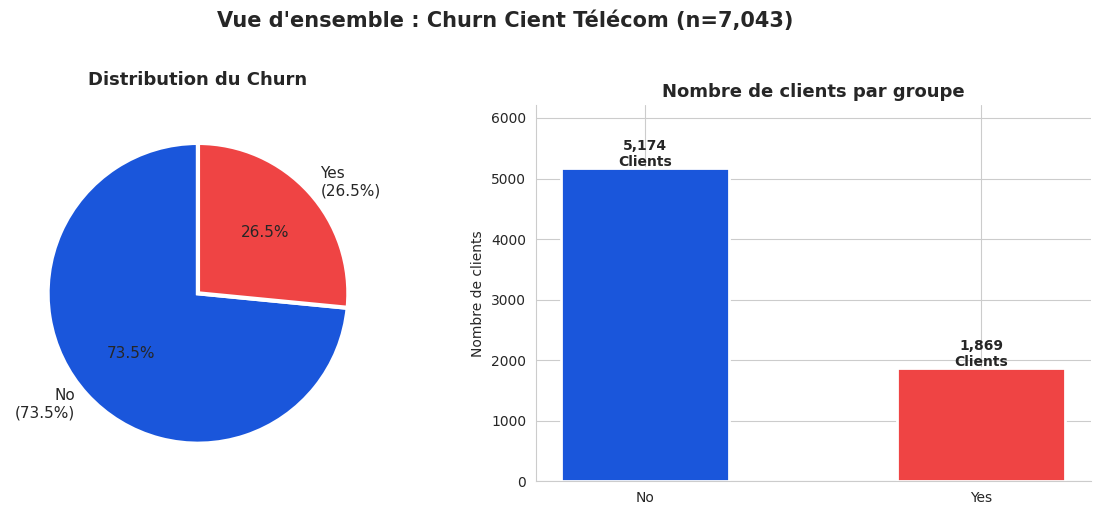

In [2]:
fig1 = plot_churn_distribution(df_eda, col='Churn', save_as='01_churn_distribution.png')

D'après les graphiques:

**Camembert** : la majorité des clients ne résilient pas (soit 73.5% des clients restent)

## 2. Graphique 2 - Churn par type de contrat

Sauvegarder: ../outputs/figures/02_churn_by_contract.png


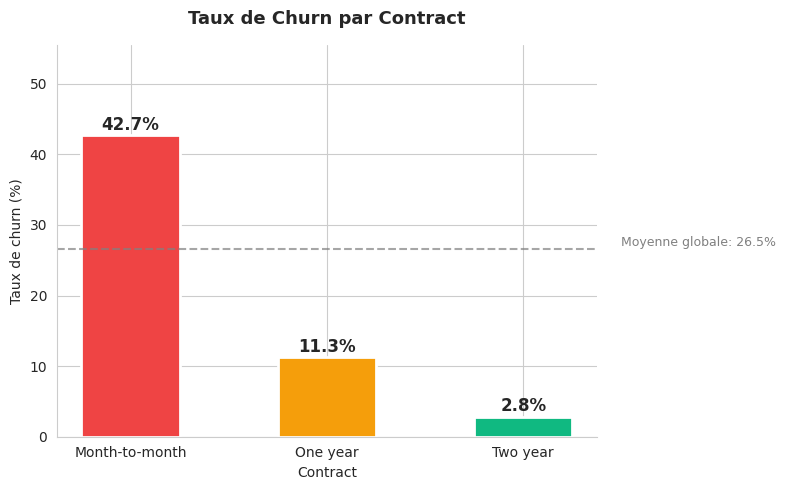

In [3]:
fig2 = plot_churn_by_category(
    df_eda,
    category_col='Contract',
    churn_col='Churn_num',
    order=['Month-to-month', 'One year', 'Two year'],
    save_as='02_churn_by_contract.png',
)

D'après le graphique, le taux de churn (départ des clients) est plus important après les mois du début des contrat.

Plus on avance dans le temps, plus ce taux de churn diminue.

## Graphique 3 - Churn vs Ancienneté

Sauvegarder: ../outputs/figures/03_churn_vs_tenure.png


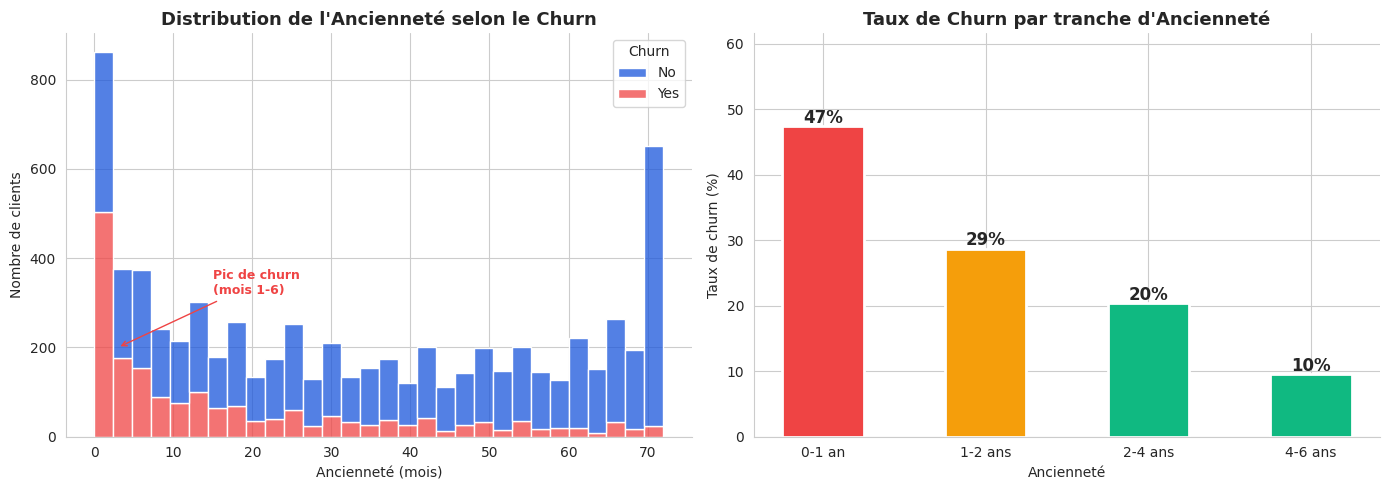

In [4]:
fig3 = plot_churn_vs_tenure(
    df_eda,         
    tenure_col='tenure',
    churn_col='Churn',         
    tenure_group_col='tenure_group',
    save_as='03_churn_vs_tenure.png',
)

**Interprétation**:

**Distribution de l'Ancienneté selon le Churn**:
Selon le graphique, le nombre de client qui churn est plus important dans les 6 premiers mois.

**Taux de Churn par Tranche d'ancienneté**:
Le taux nous confirme cette première observation, avec un taux de churn plus élevé durant la première année par rapport aux autres années.

## Graphique 4 - Matrice de Corrélation (Heatmap)

Sauvegarder: ../outputs/figures/04_Corrélation_heatmap.png


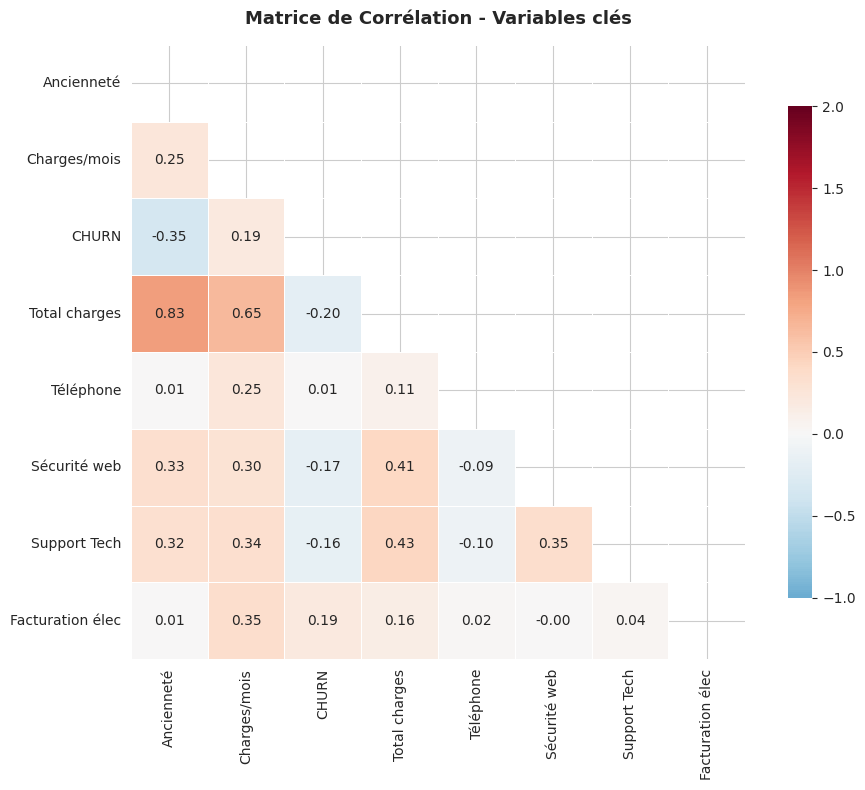

In [5]:
# Préparation d'un df numérique pour le heatmap (cf. audit : df_eda n'est pas encodé)
df_heatmap = df_eda[['tenure', 'MonthlyCharges', 'Churn_num']].copy()
df_heatmap['TotalCharges']  = pd.to_numeric(df_eda['TotalCharges'].replace(' ', None), errors='coerce')
df_heatmap['PhoneService']  = (df_eda['PhoneService'] == 'Yes').astype(int)
df_heatmap['OnlineSecurity']  = (df_eda['OnlineSecurity'] == 'Yes').astype(int)
df_heatmap['TechSupport']  = (df_eda['TechSupport'] == 'Yes').astype(int)
df_heatmap['PaperlessBilling']  = (df_eda['PaperlessBilling'] == 'Yes').astype(int)

rename = {
    'tenure': 'Ancienneté', 'MonthlyCharges': 'Charges/mois',
    'TotalCharges': 'Total charges', 'PhoneService': 'Téléphone',
    'OnlineSecurity': 'Sécurité web', 'TechSupport': 'Support Tech',
    'PaperlessBilling': 'Facturation élec', 'Churn_num': 'CHURN',
}

fig4 = plot_correlation_heatmp(
    df_heatmap,
    rename_map= rename,
    save_as='04_Corrélation_heatmap.png',
)

**Interprétation**:

Ce graphique nous indique le niveau de corrélation entre les variables clés.
Les éléments fortement corrélés sont les éléments dans la couleur tend vers le rouge : les deux variables augmente ensemble.

Et à contrario, les éléments faiblement corrélés sont les éléments dans la couleur tend vers le bleu: plus une variable augmente quand l'autre diminue

Les éléments les plus corrélés sont l'Ancienneté (tenure) et total charges (TotalCharges): plus un client reste longtemps, plus sa il paie. 

Les éléments les moins corrélés sont l'Ancienneté (tenure) et CHURN (départ): les clients récents churnent plus.